## MMTHE01 - Masters Thesis

### E1. Thesis - Apply and Evaluate different XAI methods - Case Study with ANN Model
* Applying XAI on a Supervised Learning AI model (ANN with SMOTE)
* Applying Model Agnostic Perturbation-based global XAI methods: SP-LIME, NormLIME, Permutation Importance, Adversarial Explanations

#### Importing the libraries

In [1]:
### import general libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import time
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import re

from sklearn.preprocessing import LabelEncoder

In [2]:
### Import libraries to save models
import pickle
from tensorflow.keras.models import Model, load_model

In [3]:
# Fix the random seed so that the same sample is always chosen
np.random.seed(1)

In [4]:
## Check your current working directory
cwd = os.getcwd()

# Build the full path
full_path = r"C:\Users\eaber\Documents\Master Thesis Final\Analysis"

# Check if it exists before changing
if os.path.exists(full_path):
    os.chdir(full_path)
    print("Changed directory to:", full_path)
else:
    print("Folder does not exist:", full_path)

Folder does not exist: C:\Users\eaber\Documents\Master Thesis Final\Analysis


#### Loading the test and train datasets

In [5]:
with open("saved_data/Oversampled_datasets_folder.pkl","rb") as f:
    X_train_np, y_train_np, X_test_np, y_test_np, X_train_scaled_np, X_test_scaled_np = pickle.load(f)

In [6]:
### Import the pickle saved dataset
with open("saved_data/selected_features_final.pkl","rb") as f:
    selected_features_final = pickle.load(f)

In [7]:
if 'default_status' in selected_features_final:
    selected_features_final.remove('default_status')
    
feature_names = [re.sub(r"[ <>+]", "_", c).replace(" ", "_") for c in selected_features_final]

In [8]:
# Convert to dataframe
#X_train = pd.DataFrame(X_train_np, columns=feature_names).apply(pd.to_numeric)
#X_test = pd.DataFrame(X_test_np, columns=feature_names).apply(pd.to_numeric)
X_train_scaled_full = pd.DataFrame(X_train_scaled_np, columns=feature_names).apply(pd.to_numeric)
X_test_scaled_full = pd.DataFrame(X_test_scaled_np, columns=feature_names).apply(pd.to_numeric)

y_train_full = pd.DataFrame(y_train_np, columns=['default_status'])
y_test_full = pd.DataFrame(y_test_np, columns=['default_status'])

#### Obtaining samples for the evaluation (top X train, top y test)

In [9]:
X_train_scaled = X_train_scaled_full #.head(200)
X_test_scaled = X_test_scaled_full #.head(40)

In [10]:
y_train = y_train_full #.head(200)
y_test = y_test_full #.head(40)

#### Loading the models

In [11]:
# load ANN model
model = load_model("saved_models/ann_model_Oversampled.keras")

In [12]:
import sys, os
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')
    try:
        yield
    finally:
        sys.stdout.close()
        sys.stdout = old_stdout

In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin

'''
Create an sklearn wrapper to prevent 
AttributeError: Sequential has none of the following attributes: decision_function, predict_proba.
'''
class SklearnANNWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        # set classes for binary classification
        self.classes_ = np.array([0, 1])
    
    def fit(self, X, y=None):
        # dummy fit
        return self
    
    def predict(self, X):
        return (self.model.predict(X) > 0.5).astype(int)
    
    def predict_proba(self, X):
        probs = self.model.predict(X)
        return np.hstack([1 - probs, probs])

In [14]:
# Wrap your trained model
sklearn_model = SklearnANNWrapper(model)

#### Function to combine scores of One Hot Encoded (OHE) features and show original feature names

In [15]:
original_features = ['title', 'sub_grade', 'issue_year', 'verification_status', 'loan_amnt', 'home_ownership', 'mo_sin_old_il_acct', 'dti', 
                     'acc_open_past_24mths', 'total_il_high_credit_limit', 'issue_month', 'mths_since_recent_inq', 'total_bc_limit', 'purpose',
                     'tot_hi_cred_lim', 'emp_title', 'num_tl_op_past_12m', 'num_bc_tl', 'avg_cur_bal', 'annual_inc', 'num_actv_bc_tl',
                     'percent_bc_gt_75', 'pub_rec_bankruptcies', 'term_in_months', 'mo_sin_rcnt_tl', 'pct_tl_nvr_dlq', 'mo_sin_old_rev_tl_op', 
                     'num_actv_rev_tl', 'num_tl_30dpd', 'earliest_cr_line_year', 'mths_since_recent_bc', 'revol_bal', 'revol_util', 'total_rev_hi_lim', 
                     'inq_last_6mths', 'bc_util', 'num_accts_ever_120_pd', 'earliest_cr_line_month', 'mort_acc', 'bc_open_to_buy', 'num_tl_90g_dpd_24m', 
                     'total_bal_ex_mort', 'num_bc_sats', 'num_il_tl', 'delinq_2yrs', 'num_rev_accts', 'num_op_rev_tl', 'pub_rec', 'initial_list_status',
                     'tax_liens', 'open_acc', 'delinq_amnt', 'total_acc', 'emp_length', 'collections_12_mths_ex_med', 'mo_sin_rcnt_rev_tl_op']

In [16]:
ohe_mapping = {
    'emp_length': ['emp_length_1_year', 'emp_length_10__years', 'emp_length_2_years', 'emp_length_3_years', 'emp_length_4_years', 'emp_length_5_years',	
                   'emp_length_6_years', 'emp_length_7_years', 'emp_length_8_years', 'emp_length_9_years', 'emp_length___1_year'],
    'home_ownership': ['home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN',
                       'home_ownership_RENT'],
    'verification_status': ['verification_status_Not_Verified', 'verification_status_Source_Verified', 'verification_status_Verified'],
    'purpose': ['purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house',
                'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business',
                'purpose_vacation', 'purpose_wedding'],
    'issue_month': ['issue_month_Jan', 'issue_month_Feb', 'issue_month_Mar','issue_month_Apr','issue_month_May', 'issue_month_Jun', 'issue_month_Jul',
                   'issue_month_Aug', 'issue_month_Sep', 'issue_month_Oct', 'issue_month_Nov', 'issue_month_Dec'],
    'earliest_cr_line_month': ['earliest_cr_line_month_Jan', 'earliest_cr_line_month_Feb', 'earliest_cr_line_month_Mar','earliest_cr_line_month_Apr',
                    'earliest_cr_line_month_May', 'earliest_cr_line_month_Jun', 'earliest_cr_line_month_Jul','earliest_cr_line_month_Aug', 
                    'earliest_cr_line_month_Sep', 'earliest_cr_line_month_Oct', 'earliest_cr_line_month_Nov', 'earliest_cr_line_month_Dec'],
    'initial_list_status': ['initial_list_status_f', 'initial_list_status_w']
}

In [17]:
non_ohe_features = ['title', 'sub_grade', 'issue_year',  'loan_amnt', 'mo_sin_old_il_acct', 'dti', 'acc_open_past_24mths', 'total_il_high_credit_limit',
                    'mths_since_recent_inq', 'total_bc_limit', 'tot_hi_cred_lim', 'emp_title', 'num_tl_op_past_12m', 'num_bc_tl', 'avg_cur_bal', 
                    'annual_inc', 'num_actv_bc_tl', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'term_in_months', 'mo_sin_rcnt_tl', 'pct_tl_nvr_dlq', 
                    'mo_sin_old_rev_tl_op', 'num_actv_rev_tl', 'num_tl_30dpd', 'earliest_cr_line_year', 'mths_since_recent_bc', 'revol_bal', 
                    'revol_util', 'total_rev_hi_lim', 'inq_last_6mths', 'bc_util', 'num_accts_ever_120_pd', 'mort_acc', 'bc_open_to_buy', 
                    'num_tl_90g_dpd_24m',  'total_bal_ex_mort', 'num_bc_sats', 'num_il_tl', 'delinq_2yrs', 'num_rev_accts', 'num_op_rev_tl', 'pub_rec', 
                    'tax_liens', 'open_acc', 'delinq_amnt', 'total_acc', 'collections_12_mths_ex_med', 'mo_sin_rcnt_rev_tl_op']

In [18]:
# Initialize a list to hold aggregated rows
agg_rows = []

In [19]:
def aggregate_ohe_importances_vectorized(df, feature_col='feature', importance_col='importance'):
    """
    Aggregate one-hot encoded features into their original categorical variable in a vectorized way.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing feature importances.
    ohe_features : list of str
        List of base feature names that were one-hot encoded.
    feature_col : str
        Column name for feature names.
    importance_col : str
        Column name for signed feature importance values.

    Returns:
    --------
    agg_df : pd.DataFrame
        Aggregated DataFrame with 'feature', 'importance', 'abs_importance', sorted by abs_importance descending.
    """
    
    df = df.copy()
    
    # 1. Replace original columns with base feature name
    for base_col in original_features:
        if base_col == 'title':
            df.loc[df[feature_col].str.startswith(base_col), feature_col] = base_col
        elif base_col == 'pub_rec':
            pattern = r'\b' + re.escape(base_col) + r'\b'
            df[feature_col] = df[feature_col].str.replace(pattern, base_col, regex=True)
        else:
            df[feature_col] = df[feature_col].apply(lambda x: base_col if base_col in x else x)
    
    # 2. Group by feature and sum importance values
    agg_df = df.groupby(feature_col, as_index=False)[importance_col].sum()
    
    # 3. Create absolute importance column
    agg_df['abs_'+importance_col] = agg_df[importance_col].abs()
    
    # 4. Sort by absolute importance descending
    agg_df = agg_df.sort_values(by='abs_'+importance_col, ascending=False).reset_index(drop=True)
    
    return agg_df

In [20]:
# Increase global font sizes
plt.rcParams.update({
    "font.size": 14,           # base font size
    "axes.titlesize": 16,      # title
    "axes.labelsize": 14,      # x/y labels
    "xtick.labelsize": 14,     # x tick labels
    "ytick.labelsize": 14      # y tick labels
})

### 5 Applying XAI methods to the ANN Model

#### 5.4 Applying SHAP (Gloabl Implementation) to the ANN Model
* E3B. Thesis - Test different XAI methods with the ANN Model (SHAP-Global)

In [21]:
### import
import shap
shap.initjs()

In [22]:
start_time = time.time()

In [23]:
shap_explainer = shap.DeepExplainer(model, X_train_scaled.head(200))

C:\Users\eaber\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


In [24]:
shap_explainer

In [25]:
# Single row to explain
x_to_explain = X_test_scaled.to_numpy().astype("float32")  # shape (n_records, n_features)

In [26]:
shap_values = shap_explainer.shap_values(x_to_explain)

In [27]:
end_time = time.time()
training_time = end_time - start_time
print(f"SHAP on ANN (Explanation Time): {training_time:.2f} seconds")

SHAP on ANN (Explanation Time): 215.21 seconds


In [28]:
shap_values = np.round(shap_values, 3)

In [29]:
shap_array = np.squeeze(shap_values)
shap_array

array([[-0.023,  0.004,  0.   , ..., -0.014,  0.001, -0.009],
       [ 0.011,  0.005, -0.002, ..., -0.02 ,  0.003, -0.008],
       [-0.023,  0.001,  0.   , ...,  0.006,  0.009, -0.013],
       ...,
       [-0.024,  0.012,  0.003, ..., -0.019, -0.   , -0.008],
       [-0.004,  0.001,  0.   , ...,  0.007,  0.001, -0.005],
       [-0.004,  0.009,  0.003, ..., -0.026,  0.   , -0.007]])

In [30]:
shap_df = pd.DataFrame(shap_array, columns=X_test_scaled.columns)
shap_df.head(2)

,acc_open_past_24mths,annual_inc,avg_cur_bal,bc_open_to_buy,bc_util,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earliest_cr_line_month_Apr,...,title,tot_hi_cred_lim,total_acc,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,total_rev_hi_lim,verification_status_Not_Verified,verification_status_Source_Verified,verification_status_Verified
0,-0.023,0.004,0.000,-0.0,0.000,-0.0,-0.002,-0.0,-0.015,0.0,...,0.032,0.006,-0.011,-0.007,0.007,0.008,0.0,-0.014,0.001,-0.009
1,0.011,0.005,-0.002,-0.0,0.004,-0.0,-0.004,-0.0,-0.004,0.0,...,-0.013,-0.002,-0.003,-0.008,0.012,0.004,0.0,-0.020,0.003,-0.008


In [31]:
for non_ohe_value in non_ohe_features:
    ohe_mapping[non_ohe_value] = [non_ohe_value]

In [32]:
# Aggregate by summing absolute SHAP contributions of OHE columns
agg_shap_dict = {}
for feature, cols in ohe_mapping.items():
    agg_shap_dict[feature] = shap_df[cols].sum(axis=1)  # sum across one-hot columns

In [33]:
# Convert to DataFrame
agg_shap_df = pd.DataFrame(agg_shap_dict)
agg_shap_df.head(1)

,emp_length,home_ownership,verification_status,purpose,issue_month,earliest_cr_line_month,initial_list_status,title,sub_grade,issue_year,...,delinq_2yrs,num_rev_accts,num_op_rev_tl,pub_rec,tax_liens,open_acc,delinq_amnt,total_acc,collections_12_mths_ex_med,mo_sin_rcnt_rev_tl_op
0,0.002,0.018,-0.022,-0.006,0.019,-0.01,-0.001,0.032,-0.071,-0.084,...,-0.002,0.004,-0.003,0.0,-0.001,0.004,0.0,-0.011,0.0,0.002


In [34]:
agg_shap_values = agg_shap_df.values

agg_shap_exp = shap.Explanation(
    values=agg_shap_values,
    base_values=np.zeros(X_test_scaled.shape[0]),  # or use explainer.expected_value if available
    data=agg_shap_df,                      # aggregated feature values
    feature_names=agg_shap_df.columns
)

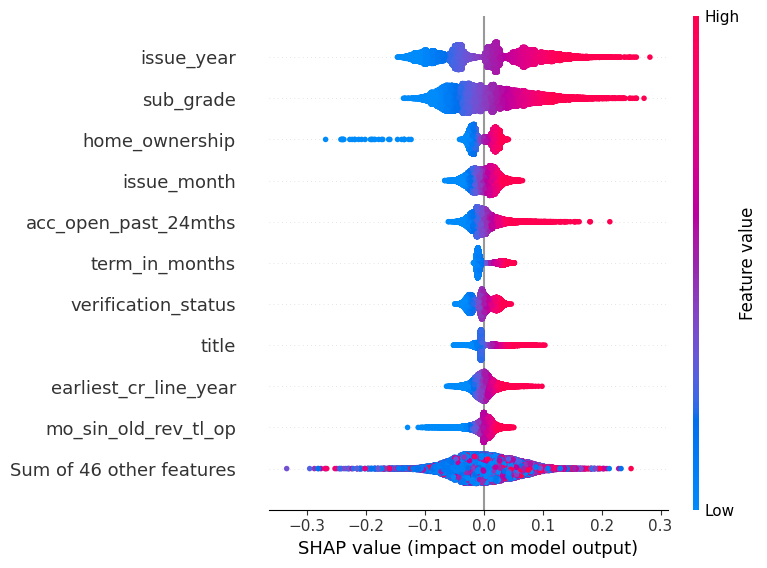

In [35]:
shap.plots.beeswarm(agg_shap_exp, max_display=11, show=False)
plt.tight_layout()
plt.savefig('intermediate_output/XAI top 10 features graphs/ANN_shap_global_top10_beeswarm', dpi=300)

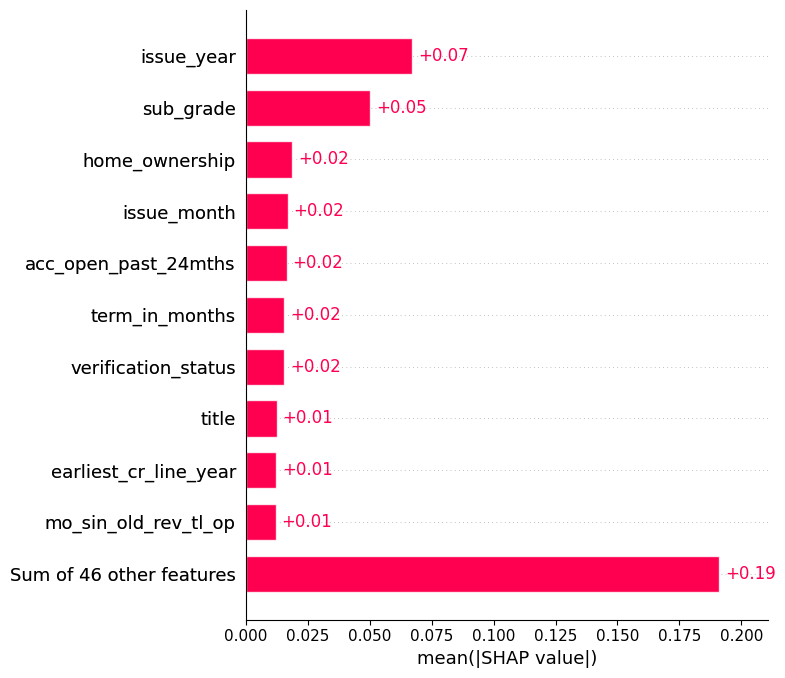

In [36]:
shap.plots.bar(agg_shap_exp, max_display=11, show=False)
plt.tight_layout()
plt.savefig('intermediate_output/XAI top 10 features graphs/ANN_shap_global_top10_bar', dpi=300)

##### Adding SHAP values to an arbitrary bar chart

In [37]:
agg_shap_df.head(1)

,emp_length,home_ownership,verification_status,purpose,issue_month,earliest_cr_line_month,initial_list_status,title,sub_grade,issue_year,...,delinq_2yrs,num_rev_accts,num_op_rev_tl,pub_rec,tax_liens,open_acc,delinq_amnt,total_acc,collections_12_mths_ex_med,mo_sin_rcnt_rev_tl_op
0,0.002,0.018,-0.022,-0.006,0.019,-0.01,-0.001,0.032,-0.071,-0.084,...,-0.002,0.004,-0.003,0.0,-0.001,0.004,0.0,-0.011,0.0,0.002


In [38]:
# Compute mean per column and convert to DataFrame
shap_df = pd.DataFrame(agg_shap_df.abs().mean()).reset_index()
shap_df.columns = ['feature', 'shap_value_mean']
shap_df['abs_shap_value_mean'] = shap_df['shap_value_mean'].apply(lambda x:abs(x))

In [39]:
shap_df.head(1)

,feature,shap_value_mean,abs_shap_value_mean
0,emp_length,0.007181,0.007181


In [40]:
shap_df.sort_values('abs_shap_value_mean', ascending=False).to_csv('intermediate_output/XAI all features ranked/ANN_shap_global_allR.csv',index=False)

In [41]:
# Sort by absolute SHAP value
shap_top10 = shap_df.sort_values('abs_shap_value_mean', ascending=False).head(10)
shap_top10.to_csv('intermediate_output/XAI top 10 features/ANN_shap_global_top10.csv',index=False)

In [42]:
def plot_bar_customer(column_to_plot):
    # shap_top10 should have columns: 'feature' and 'shap_value' (signed)
    # Sort to have the largest absolute SHAP values on top
    shap_values_top10 = shap_top10.reindex(shap_top10[column_to_plot].abs().sort_values(ascending=False).index)
    
    plt.figure(figsize=(10, 6))
    
    # Plot horizontal bars
    bars = plt.barh(shap_values_top10['feature'], shap_values_top10[column_to_plot], color='teal')
    plt.gca().invert_yaxis()  # largest on top
    plt.xlabel("SHAP Value")
    plt.title("Top 10 Feature Contributions - ANN (Global SHAP)")
    
    # Add SHAP value labels from the DataFrame (signed values)
    for i, bar in enumerate(bars):
        value = shap_top10[column_to_plot].iloc[i]
        plt.text(value + 0.001 if value > 0 else value - 0.001,
                 bar.get_y() + bar.get_height()/2,
                 f'{value:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()

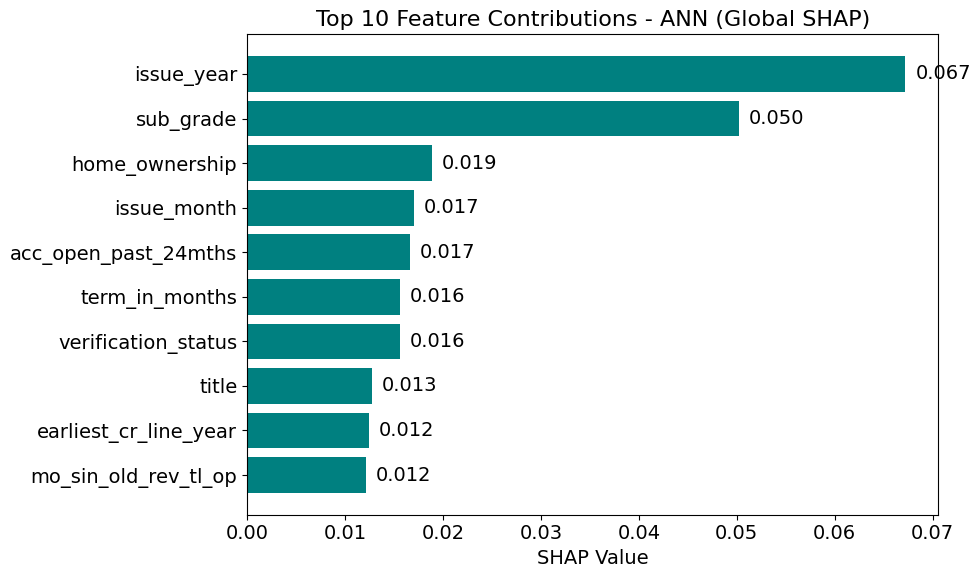

In [43]:
plot_bar_customer('shap_value_mean')

#### 5.5 Applying Submodular Pick (SP)-LIME to the ANN Model
* E3B. Thesis - Test different XAI methods with the ANN Model (SP-LIME)
* This is a variant of LIME

In [44]:
# Fix the random seed so that the same sample is always chosen
np.random.seed(1)

In [45]:
import lime
import lime.lime_tabular
from lime import submodular_pick

In [46]:
feature_names = X_test_scaled.columns.tolist()

In [47]:
sample_size = 100 #int(round(len(X_test_scaled)*0.1))
num_exps_desired = 5

In [48]:
# Wrapper function for LIME
def predict_proba_wrapper(x):
    # model.predict(x) -> shape (n_samples, 1)
    p1 = model.predict(x)
    p0 = 1 - p1
    return np.hstack([p0, p1])  # shape (n_samples, 2)

In [49]:
start_time = time.time()

In [50]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test_scaled.values,
    feature_names=feature_names,
    class_names=["non-default", "default"],
    mode='classification',
    verbose=True,
    random_state = 1
)

In [51]:
# Initialize the SubmodularPick object
with suppress_stdout():
    sp_obj = submodular_pick.SubmodularPick(
        lime_explainer,
        X_test_scaled.values,
        predict_proba_wrapper,
        sample_size=sample_size,
        num_features=len(X_test_scaled.columns.tolist()),
        num_exps_desired=num_exps_desired
    )

In [52]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"SP-LIME on ANN (Explanation Time): {explanation_time:.2f} seconds")

SP-LIME on ANN (Explanation Time): 63.78 seconds


In [53]:
selected_explanations = sp_obj.explanations[:num_exps_desired]

#### Obtaining average of the 5 results

In [54]:
# Step 1: Collect contributions into a DataFrame
all_contribs = []

for exp in selected_explanations:
    # Take the predicted class for this instance
    predicted_class = list(exp.local_exp.keys())[0]
    
    # Convert list of (feature_index, contribution) to dict: {feature_name: contribution}
    contrib_dict = dict(exp.local_exp[predicted_class])
    
    # Optionally, convert feature indices to feature names
    feature_names = [exp.domain_mapper.feature_names[i] for i in contrib_dict.keys()]
    contrib_dict_named = {name: contrib_dict[i] for i, name in zip(contrib_dict.keys(), feature_names)}
    
    all_contribs.append(contrib_dict_named)

# Step 2: Convert list of dicts to DataFrame
df = pd.DataFrame(all_contribs).fillna(0)  # fill missing features with 0

# Step 3: Compute average contribution for each feature
average_amounts = df.mean(axis=0).sort_values(ascending=False)

df_avg_ohe = (
    df.mean(axis=0)
      .sort_values(ascending=False)
      .to_frame(name="average_contribution")
).reset_index().rename(columns={'index':'feature'})

In [55]:
len(df_avg_ohe)

109

In [56]:
df_avg = aggregate_ohe_importances_vectorized(df_avg_ohe, feature_col='feature', importance_col='average_contribution')
len(df_avg)

56

In [57]:
df_avg = aggregate_ohe_importances_vectorized(df_avg_ohe, feature_col='feature', importance_col='average_contribution')
df_avg.to_csv('intermediate_output/XAI all features ranked/ANN_splime_allR.csv',index=False)
len(df_avg)

56

In [58]:
# Display top 10 features
top10_df = df_avg.head(10)
top10_df.to_csv('intermediate_output/XAI top 10 features/ANN_splime_top10.csv',index=False)
top10_df

,feature,average_contribution,abs_average_contribution
0,purpose,-0.257995,0.257995
1,home_ownership,-0.121250,0.121250
2,sub_grade,0.047603,0.047603
3,acc_open_past_24mths,0.030743,0.030743
4,issue_year,0.029873,0.029873
5,verification_status,0.024788,0.024788
6,emp_length,-0.022244,0.022244
7,tax_liens,0.018874,0.018874
8,term_in_months,0.017224,0.017224
9,delinq_amnt,-0.017065,0.017065


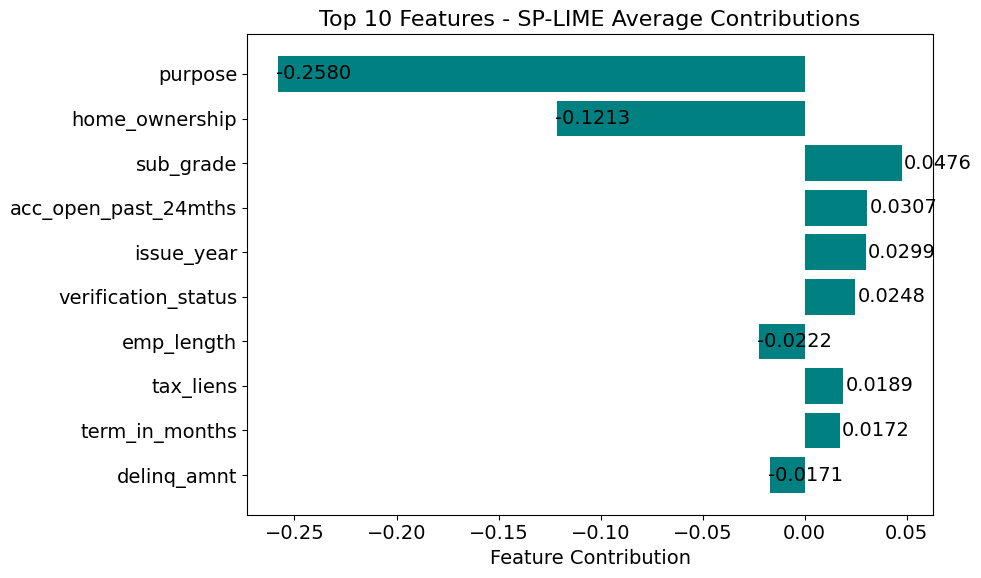

In [59]:
# Plot horizontal bar chart
plt.figure(figsize=(10,6))
bars = plt.barh(top10_df["feature"], top10_df["average_contribution"], color='teal')
plt.xlabel("Feature Contribution")
plt.title("Top 10 Features - SP-LIME Average Contributions")

# Add labels
for bar, val in zip(bars, top10_df["average_contribution"]):
    plt.text(bar.get_width() + 0.001 if val > 0 else bar.get_width() - 0.001, 
             bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center')

plt.gca().invert_yaxis()  # largest on top

plt.tight_layout()
plt.savefig('intermediate_output/XAI top 10 features graphs/ANN_splime_top10', dpi=300)
plt.show()

#### 5.6 Applying Permutation Importance to the ANN Model
* E3B. Thesis - Test different XAI methods with the ANN Model (Permutation Importance)

In [60]:
from sklearn.inspection import permutation_importance

In [61]:
start_time = time.time()

In [62]:
# Compute permutation importance
with suppress_stdout():
    result = permutation_importance(
        sklearn_model, X_test_scaled, y_test,
        n_repeats=5, random_state=1, scoring='roc_auc'
    )

In [63]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"Permutation Important on ANN (Explanation Time): {explanation_time:.2f} seconds")

Permutation Important on ANN (Explanation Time): 1263.83 seconds


In [64]:
# Store results in DataFrame
pi_df_ohe = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

In [65]:
pi_df = aggregate_ohe_importances_vectorized(pi_df_ohe, feature_col='feature', importance_col='importance_mean')
pi_df.to_csv('intermediate_output/XAI all features ranked/ANN_permutation_importance_allR.csv',index=False)

In [66]:
pi_df.head(10)

,feature,importance_mean,abs_importance_mean
0,issue_year,0.070328,0.070328
1,sub_grade,0.046270,0.046270
2,acc_open_past_24mths,0.005002,0.005002
3,purpose,0.004722,0.004722
4,home_ownership,0.003875,0.003875
5,term_in_months,0.003513,0.003513
6,earliest_cr_line_year,0.003211,0.003211
7,mo_sin_old_rev_tl_op,0.003082,0.003082
8,issue_month,0.003078,0.003078
9,tot_hi_cred_lim,0.002344,0.002344


In [67]:
# Plot top 10 features with labels
top_n = 10
features = pi_df['feature'].head(top_n)[::-1]
importances = pi_df['importance_mean'].head(top_n)[::-1]
pi_df.head(top_n).to_csv('intermediate_output/XAI top 10 features/ANN_permutation_importance_top10.csv',index=False)

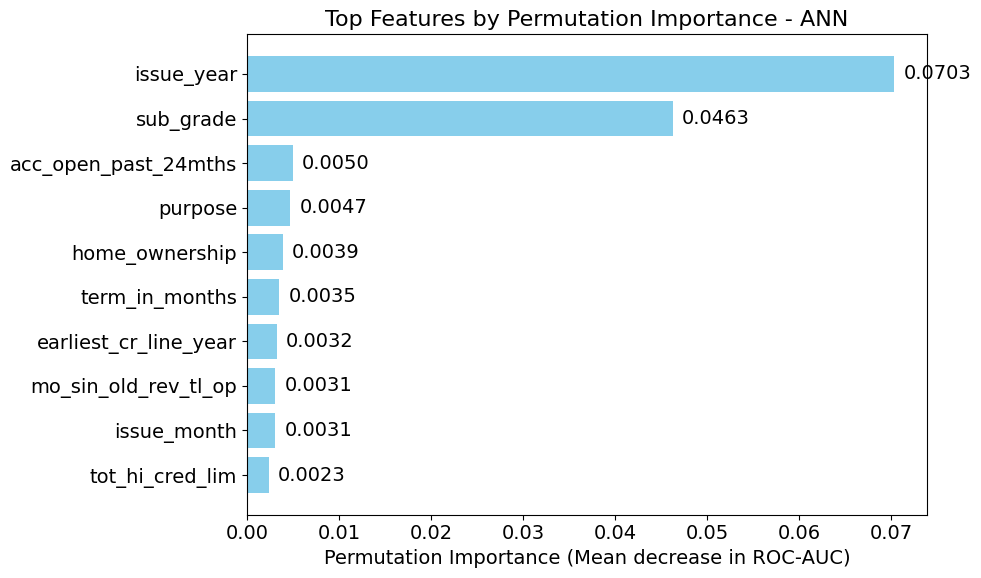

In [68]:
plt.figure(figsize=(10,6))
bars = plt.barh(features, importances, color='skyblue')
plt.xlabel("Permutation Importance (Mean decrease in ROC-AUC)")
plt.title("Top Features by Permutation Importance - ANN")

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f"{width:.4f}", va='center')

plt.tight_layout()
plt.savefig('intermediate_output/XAI top 10 features graphs/ANN_permutation_importance_top10', dpi=300)
plt.show()